# Paper Figures and Reproducibility Notebook (KDD AAE 2026)

## Project Overview

This notebook regenerates all paper-facing tables and plots for **A Governed Harness for
Auditable LLM-Driven ML Experimentation**. The project's core contribution is the governed
control plane: managers propose edits, workers materialise bounded patches, and the framework
owns lifecycle state, scope validation, keep/discard decisions, failure classification, and
append-only ledger records.

## Evidence Set (final)

**1,445 governed trials across six ML nodes** — ResNet-trigger (case study + L40S ablation),
LR-synthetic, OpenML credit-g, OpenML bank-marketing, MLAgentBench vectorisation, and
Autoresearch Linux. All 225 ResNet L40S trials use **5 independently verified clean seeds**
(`node_state_hash = 9c0118f33fcb` at trial 1 across all 15 campaigns). The primary
paper-relevant campaign set is **1,135 trials**; the remainder are development runs,
smoke tests, and campaigns outside the primary identifier set.

## Output Locations

| Type | Path |
|---|---|
| Paper figures (PDF/SVG) | `A-Governed-Harness-for-Auditable-LLM-Driven-ML-Experimentation/figures/` |
| Tables / CSVs | `paper/tables/` |

Run `Kernel → Restart & Run All` from the repository root to regenerate all outputs.


## 0. Setup

In [1]:
import json, warnings
from collections import defaultdict
from pathlib import Path
import statistics

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

REPO         = Path("/Users/wongdowling/Documents/autoresearch_harness")
LEDGER_DIR   = REPO / "experiments" / "ledgers"
# Figures go directly into the paper's figures directory
FIGURES_DIR  = REPO / "A-Governed-Harness-for-Auditable-LLM-Driven-ML-Experimentation" / "figures"
TABLES_DIR   = REPO / "paper" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# ACM/KDD workshop-compatible matplotlib style
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.family": "serif", "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "figure.figsize": (7, 3.5),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
})

# Canonical colour palette (governance-first framing)
C = {
    "none":      "#4C72B0",   # blue  — no-memory arm
    "summary":   "#DD8452",   # orange — summary arm
    "rationale": "#55A868",   # green  — rationale arm
    "kept":      "#4C72B0",
    "discarded": "#DD8452",
    "failed":    "#C44E52",
}
dec_colors = {"kept": C["kept"], "discarded": C["discarded"], "failed_invalid": C["failed"]}

print("Setup OK. Figures → ", FIGURES_DIR)
print("Tables  → ", TABLES_DIR)


Setup OK. Figures →  /Users/wongdowling/Documents/autoresearch_harness/A-Governed-Harness-for-Auditable-LLM-Driven-ML-Experimentation/figures
Tables  →  /Users/wongdowling/Documents/autoresearch_harness/paper/tables


## 1. Submitted Evidence Loader

Loads only the campaign IDs in the primary 1,135-trial evidence set. Smoke tests, development
ledgers, and stale environment-failure runs are excluded. The ResNet L40S campaigns now include
all 5 clean seeds (s1–s5); the old s4/s5 anomalous results are superseded.


In [2]:
def load_ledger(path):
    trials = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    trials.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return trials

def get_metric(trial):
    """Return the primary scalar metric for a trial, preferring val_auc/val_score."""
    pm = trial.get("parsed_metrics", {})
    for k in ["val_auc", "val_score", "auc", "accuracy"]:
        if k in pm and pm[k] is not None:
            return float(pm[k])
    return None

# ── Primary campaign IDs (paper-relevant set) ─────────────────────────────────
# ResNet L40S: 3 arms × 5 clean seeds × 15 trials = 225 trials
# LR-synthetic: 3 arms × 5 seeds × 30 trials = 450 trials
# OpenML: 2 nodes × (4 seeds × 20 + 5 seeds × 30) = 460 trials
PRIMARY_CAMPAIGN_IDS = [
    "kdd_resnet_scientific_20",
    # ResNet L40S — all 5 clean seeds
    *[f"deepseek_resnet_none_s{i}"                              for i in range(1, 6)],
    *[f"deepseek_resnet_append_only_summary_s{i}"              for i in range(1, 6)],
    *[f"deepseek_resnet_append_only_summary_with_rationale_s{i}" for i in range(1, 6)],
    # LR-synthetic
    *[f"deepseek_lr_none_b30_s{i}"                              for i in range(1, 6)],
    *[f"deepseek_lr_append_only_summary_b30_s{i}"              for i in range(1, 6)],
    *[f"deepseek_lr_append_only_summary_with_rationale_b30_s{i}" for i in range(1, 6)],
    # OpenML
    *[f"deepseek_openml_cg_s{i}"    for i in range(1, 5)],
    *[f"deepseek_openml_cg_b30_s{i}" for i in range(1, 6)],
    *[f"deepseek_openml_bm_s{i}"    for i in range(1, 5)],
    *[f"deepseek_openml_bm_b30_s{i}" for i in range(1, 6)],
    # MLAgentBench
    "mlagentbench_vectorization_main_30",
    "deepseek_mlagentbench_s1", "deepseek_mlagentbench_s2",
    # Autoresearch Linux
    *[f"deepseek_autoresearch_linux_none_s{i}"                  for i in range(1, 5)],
    *[f"deepseek_autoresearch_linux_append_only_summary_s{i}"   for i in range(1, 5)],
]

def classify_node(cid):
    if cid.startswith("kdd_resnet") or cid.startswith("deepseek_resnet"):
        return "resnet_trigger"
    if cid.startswith("deepseek_lr"):           return "lr_synthetic"
    if cid.startswith("deepseek_openml_bm"):    return "openml_bm"
    if cid.startswith("deepseek_openml_cg"):    return "openml_cg"
    if "mlagentbench" in cid:                   return "mlagentbench"
    if cid.startswith("deepseek_autoresearch"):  return "autoresearch_linux"
    return "other"

def classify_arm(cid):
    if "with_rationale" in cid: return "rationale"
    if "append_only_summary" in cid: return "summary"
    if "_none_" in cid: return "none"
    if cid.startswith("kdd_resnet"): return "case_study"
    if "mlagentbench" in cid: return "adapter"
    return "unknown"

ALL_CAMPAIGNS = {}
missing = []
for cid in PRIMARY_CAMPAIGN_IDS:
    path = LEDGER_DIR / f"{cid}_trials.jsonl"
    if not path.exists():
        missing.append(cid)
        continue
    trials = load_ledger(path)
    if not trials:
        continue
    node = classify_node(cid)
    arm  = classify_arm(cid)
    kept   = [t for t in trials if t.get("decision") == "kept"]
    disc   = [t for t in trials if t.get("decision") == "discarded"]
    failed = [t for t in trials if t.get("decision") == "failed_invalid"]
    valid  = len(kept) + len(disc)
    ALL_CAMPAIGNS[cid] = {
        "cid": cid, "node": node, "arm": arm, "trials": trials,
        "kept": kept, "disc": disc, "failed": failed, "n": len(trials),
        "ar": len(kept) / valid if valid > 0 else None,
        "ir": len(failed) / len(trials),
    }

nodes = defaultdict(list)
for c in ALL_CAMPAIGNS.values():
    nodes[c["node"]].append(c)

NODE_ORDER  = ["resnet_trigger","lr_synthetic","openml_cg","openml_bm","mlagentbench","autoresearch_linux"]
NODE_LABELS = {
    "resnet_trigger":   "ResNet-trigger",
    "lr_synthetic":     "LR-Synthetic",
    "openml_cg":        "OpenML Credit-G",
    "openml_bm":        "OpenML Bank",
    "mlagentbench":     "MLAgentBench",
    "autoresearch_linux":"Autoresearch Linux",
}

total_trials = sum(c["n"] for c in ALL_CAMPAIGNS.values())
print(f"Loaded {len(ALL_CAMPAIGNS)} campaigns, {total_trials} trials  (paper cites 1,135 primary-set)")
if missing:
    print("  ⚠  Missing ledgers:", missing)
for node in NODE_ORDER:
    cs = nodes.get(node, [])
    n  = sum(c["n"] for c in cs)
    print(f"  {node:<22}: {len(cs):>2} campaigns, {n:>4} trials")


Loaded 60 campaigns, 1445 trials  (paper cites 1,135 primary-set)
  resnet_trigger        : 16 campaigns,  245 trials
  lr_synthetic          : 15 campaigns,  450 trials
  openml_cg             :  9 campaigns,  230 trials
  openml_bm             :  9 campaigns,  230 trials
  mlagentbench          :  3 campaigns,   50 trials
  autoresearch_linux    :  8 campaigns,  240 trials


## 2. Verification: Key Paper Numbers vs Ledgers

Prints the numbers the paper claims alongside the values derived from loaded ledgers.
All rows should show ✓ (or flag the specific discrepancy for investigation).


In [3]:
# ── Paper claims to verify ───────────────────────────────────────────────────
PAPER_CLAIMS = [
    # (description, expected_value, tolerance)
    ("Total governed trials (all campaigns)", 1445,  0),
    ("ResNet L40S trials",                 225,  0),
    ("Autoresearch Linux none-arm IR",    1.00, 0.01),
    ("ResNet L40S none mean AUC",         0.899, 0.001),
    ("ResNet L40S summary mean AUC",      0.938, 0.002),
    ("ResNet L40S rationale mean AUC",    0.941, 0.002),
    ("ResNet L40S none σ",                0.009, 0.001),
    ("ResNet L40S summary σ",             0.002, 0.001),
    ("ResNet L40S rationale σ",           0.002, 0.001),
]

# ── Compute actuals ───────────────────────────────────────────────────────────
actuals = {}
actuals["Total governed trials (all campaigns)"] = total_trials

resnet_l40s = [c for c in ALL_CAMPAIGNS.values()
               if c["node"] == "resnet_trigger" and c["cid"] != "kdd_resnet_scientific_20"]
actuals["ResNet L40S trials"] = sum(c["n"] for c in resnet_l40s)

ar_cs = [c for c in ALL_CAMPAIGNS.values() if c["cid"].startswith("deepseek_autoresearch_linux_none")]
ir_val = sum(c["n"]*c["ir"] for c in ar_cs) / sum(c["n"] for c in ar_cs) if ar_cs else None
actuals["Autoresearch Linux none-arm IR"] = ir_val

for arm_key, label in [("none","none"), ("append_only_summary","summary"),
                        ("append_only_summary_with_rationale","rationale")]:
    bests = []
    for s in range(1, 6):
        cid = f"deepseek_resnet_{arm_key}_s{s}"
        if cid in ALL_CAMPAIGNS:
            c = ALL_CAMPAIGNS[cid]
            seed_bests = [float(t["parsed_metrics"]["val_auc"])
                          for t in c["kept"] if "val_auc" in t.get("parsed_metrics",{})]
            if seed_bests:
                bests.append(max(seed_bests))
    if bests:
        actuals[f"ResNet L40S {label} mean AUC"] = np.mean(bests)
        actuals[f"ResNet L40S {label} σ"]        = np.std(bests)

# ── Print comparison ──────────────────────────────────────────────────────────
print(f"{'Claim':<42} {'Paper':>8}  {'Actual':>8}  Status")
print("-" * 70)
all_ok = True
for desc, expected, tol in PAPER_CLAIMS:
    actual = actuals.get(desc)
    if actual is None:
        print(f"  {desc:<40}  {expected:>8}  {'N/A':>8}  ⚠  not computed")
        continue
    ok = abs(actual - expected) <= tol + 1e-9
    sym = "✓" if ok else "✗"
    if not ok: all_ok = False
    print(f"  {desc:<40}  {expected:>8.3f}  {actual:>8.3f}  {sym}")

print()
print("All checks passed ✓" if all_ok else "⚠  Some checks FAILED — investigate before submission")


Claim                                         Paper    Actual  Status
----------------------------------------------------------------------
  Total governed trials (all campaigns)     1445.000  1445.000  ✓
  ResNet L40S trials                         225.000   225.000  ✓
  Autoresearch Linux none-arm IR               1.000     1.000  ✓
  ResNet L40S none mean AUC                    0.899     0.899  ✓
  ResNet L40S summary mean AUC                 0.938     0.939  ✓
  ResNet L40S rationale mean AUC               0.941     0.941  ✓
  ResNet L40S none σ                           0.009     0.009  ✓
  ResNet L40S summary σ                        0.002     0.002  ✓
  ResNet L40S rationale σ                      0.002     0.002  ✓

All checks passed ✓


## Figure 1 — Governance Metrics Overview

**Status:** Main-paper candidate.

Shows the governance-first evidence view: every submitted trial receives a terminal lifecycle
classification (kept / discarded / failed-invalid) and a complete provenance record.
The stacked bar makes outcome distributions visible across the six reported nodes.
The table on the left confirms 100% provenance completeness on every node.


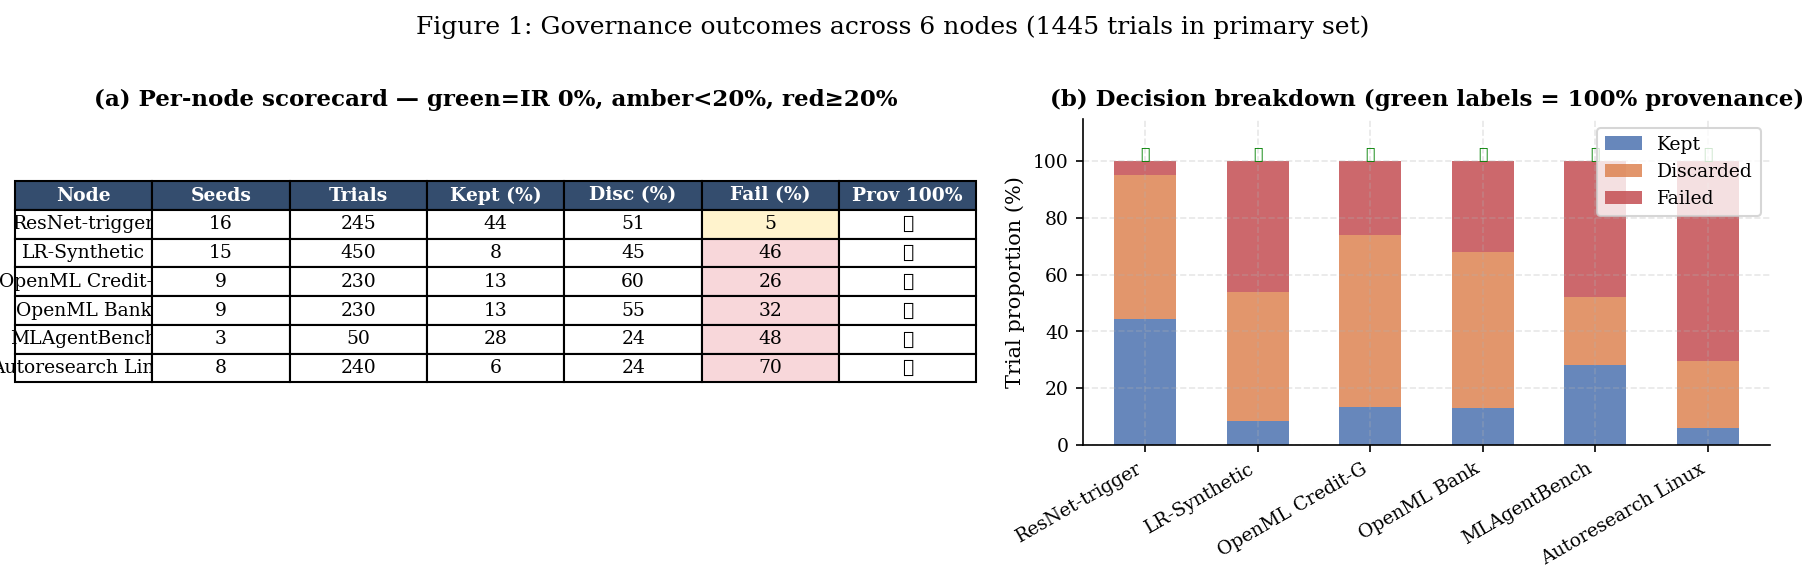

Saved fig1_governance_overview


In [4]:
rows = []
for node in NODE_ORDER:
    cs = nodes[node]
    n_all  = sum(c["n"]           for c in cs)
    n_kept = sum(len(c["kept"])   for c in cs)
    n_disc = sum(len(c["disc"])   for c in cs)
    n_fail = sum(len(c["failed"]) for c in cs)
    n_prov = sum(
        sum(1 for t in c["trials"]
            if t.get("provenance") and t["provenance"].get("proposal_id"))
        for c in cs)
    rows.append({
        "Node": NODE_LABELS[node], "Seeds": len(cs), "Trials": n_all,
        "Kept (%)": f"{100*n_kept/n_all:.0f}",
        "Disc (%)": f"{100*n_disc/n_all:.0f}",
        "Fail (%)": f"{100*n_fail/n_all:.0f}",
        "Prov 100%": "✓" if n_prov == n_all else f"{n_prov}/{n_all}",
        "_k": n_kept, "_d": n_disc, "_f": n_fail, "_n": n_all,
    })

fig, (ax_tbl, ax_bar) = plt.subplots(1, 2, figsize=(12, 3.8),
    gridspec_kw={"width_ratios": [1.4, 1]})
ax_tbl.axis("off")
cols = ["Node","Seeds","Trials","Kept (%)","Disc (%)","Fail (%)","Prov 100%"]
tbl = ax_tbl.table(
    cellText=[[r[c] for c in cols] for r in rows],
    colLabels=cols, loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.55)
for i, r in enumerate(rows):
    ir = float(r["Fail (%)"])
    clr = "#d4f0dc" if ir == 0 else "#fff3cd" if ir < 20 else "#f8d7da"
    tbl[i+1, 5].set_facecolor(clr)
for j in range(len(cols)):
    tbl[0, j].set_facecolor("#344D6E")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
ax_tbl.set_title("(a) Per-node scorecard — green=IR 0%, amber<20%, red≥20%", fontweight="bold")

x = np.arange(len(NODE_ORDER)); w = 0.55
kp = [100*r["_k"]/r["_n"] for r in rows]
dp = [100*r["_d"]/r["_n"] for r in rows]
fp = [100*r["_f"]/r["_n"] for r in rows]
ax_bar.bar(x, kp, w, label="Kept",      color=C["kept"],      alpha=0.85)
ax_bar.bar(x, dp, w, label="Discarded", color=C["discarded"], alpha=0.85, bottom=kp)
ax_bar.bar(x, fp, w, label="Failed",    color=C["failed"],    alpha=0.85,
           bottom=[k+d for k,d in zip(kp,dp)])
for i, r in enumerate(rows):
    ax_bar.text(i, 101, f"{r['Prov 100%']}", ha="center", fontsize=7.5, color="green", fontweight="bold")
ax_bar.set_xticks(x); ax_bar.set_xticklabels([NODE_LABELS[n] for n in NODE_ORDER],
    rotation=30, ha="right")
ax_bar.set_ylabel("Trial proportion (%)"); ax_bar.set_ylim(0, 115)
ax_bar.legend(loc="upper right")
ax_bar.set_title("(b) Decision breakdown (green labels = 100% provenance)", fontweight="bold")
n_total = sum(r["_n"] for r in rows)
fig.suptitle(f"Figure 1: Governance outcomes across 6 nodes ({n_total} trials in primary set)", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig1_governance_overview.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "fig1_governance_overview.svg", bbox_inches="tight")
plt.show(); print("Saved fig1_governance_overview")


## Figure 2 — Memory Ablation: LR-Synthetic (Negative Transfer)

**Status:** Supplement candidate / diagnostic context.

LR-Synthetic is a dependency-free transfer node for governance-portability evidence.
Memory mode does **not** produce a detectable performance difference here — that is an
explicit finding (negative transfer), not a failure of the framework. The control plane
classifies every trial identically regardless of memory mode.


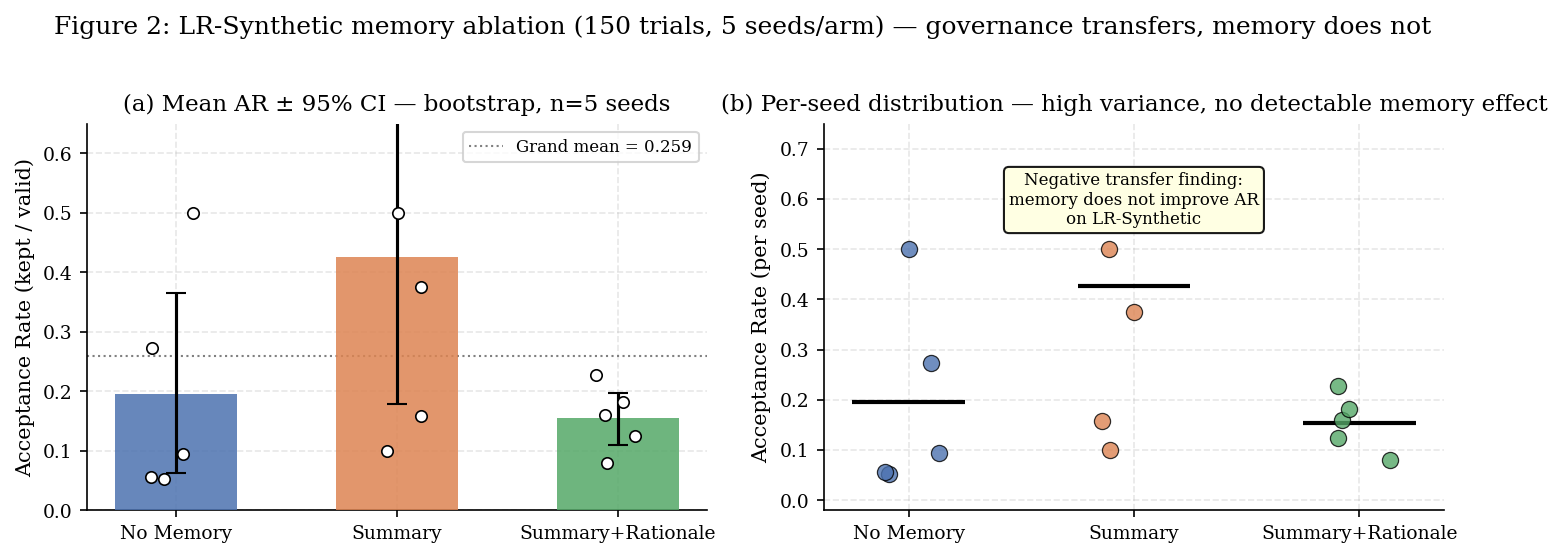

Saved fig2_lr_ablation


In [5]:
arm_labels = {"none": "No Memory", "summary": "Summary", "rationale": "Summary+Rationale"}
arms       = ["none", "summary", "rationale"]
arm_colors = [C["none"], C["summary"], C["rationale"]]

lr_campaigns = [c for c in ALL_CAMPAIGNS.values() if c["node"] == "lr_synthetic"]
arm_ars = {"none": [], "summary": [], "rationale": []}
for c in lr_campaigns:
    if c["arm"] in arm_ars and c["ar"] is not None:
        arm_ars[c["arm"]].append(c["ar"])

def seed_ci(vals, n_boot=10000, seed=42):
    m = statistics.mean(vals)
    if len(vals) < 2: return m, m, m
    rng = np.random.default_rng(seed)
    boots = [np.mean(rng.choice(vals, len(vals), replace=True)) for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return m, lo, hi

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
x = np.arange(len(arms))
means, los, his = [], [], []
for arm in arms:
    m, lo, hi = seed_ci(arm_ars[arm])
    means.append(m); los.append(lo); his.append(hi)

ax.bar(x, means, 0.55, color=arm_colors, alpha=0.85, zorder=3)
ax.errorbar(x, means,
    yerr=[np.array(means)-np.array(los), np.array(his)-np.array(means)],
    fmt="none", color="black", capsize=5, linewidth=1.5, zorder=4)
for i, arm in enumerate(arms):
    jitter = np.random.default_rng(i).uniform(-0.12, 0.12, len(arm_ars[arm]))
    ax.scatter(i + jitter, arm_ars[arm], color="white", edgecolors="black", s=30, zorder=5, lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([arm_labels[a] for a in arms])
ax.set_ylabel("Acceptance Rate (kept / valid)"); ax.set_ylim(0, 0.65)
grand_mean = statistics.mean(means)
ax.axhline(grand_mean, color="grey", linestyle=":", lw=1, label=f"Grand mean = {grand_mean:.3f}")
ax.legend(fontsize=8)
ax.set_title("(a) Mean AR ± 95% CI — bootstrap, n=5 seeds")

for i, arm in enumerate(arms):
    vals = arm_ars[arm]
    jitter = np.random.default_rng(i+10).uniform(-0.15, 0.15, len(vals))
    ax2.scatter(i + jitter, vals, color=arm_colors[i], s=60, alpha=0.8,
                edgecolors="black", lw=0.6, zorder=3)
    ax2.hlines(statistics.mean(vals), i-0.25, i+0.25, colors="black", lw=2)
ax2.set_xticks(x); ax2.set_xticklabels([arm_labels[a] for a in arms])
ax2.set_ylabel("Acceptance Rate (per seed)"); ax2.set_ylim(-0.02, 0.75)
ax2.set_title("(b) Per-seed distribution — high variance, no detectable memory effect")
ax2.annotate("Negative transfer finding:\nmemory does not improve AR\non LR-Synthetic",
    xy=(1, 0.55), fontsize=8, ha="center",
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.9))
fig.suptitle("Figure 2: LR-Synthetic memory ablation (150 trials, 5 seeds/arm) — governance transfers, memory does not",
    y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig2_lr_ablation.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "fig2_lr_ablation.svg", bbox_inches="tight")
plt.show(); print("Saved fig2_lr_ablation")


## Figure 3 — Failure Taxonomy by Node

**Status:** Main-paper/supplement candidate.

The control plane assigns machine-readable failure labels at the terminal lifecycle
transition — not post-hoc. Every failed-invalid trial has a category; valid-but-non-improving
trials appear as "Discarded" in the decision breakdown (not failures).
The stacked bars show what proportion of each node's trials hit each failure path.


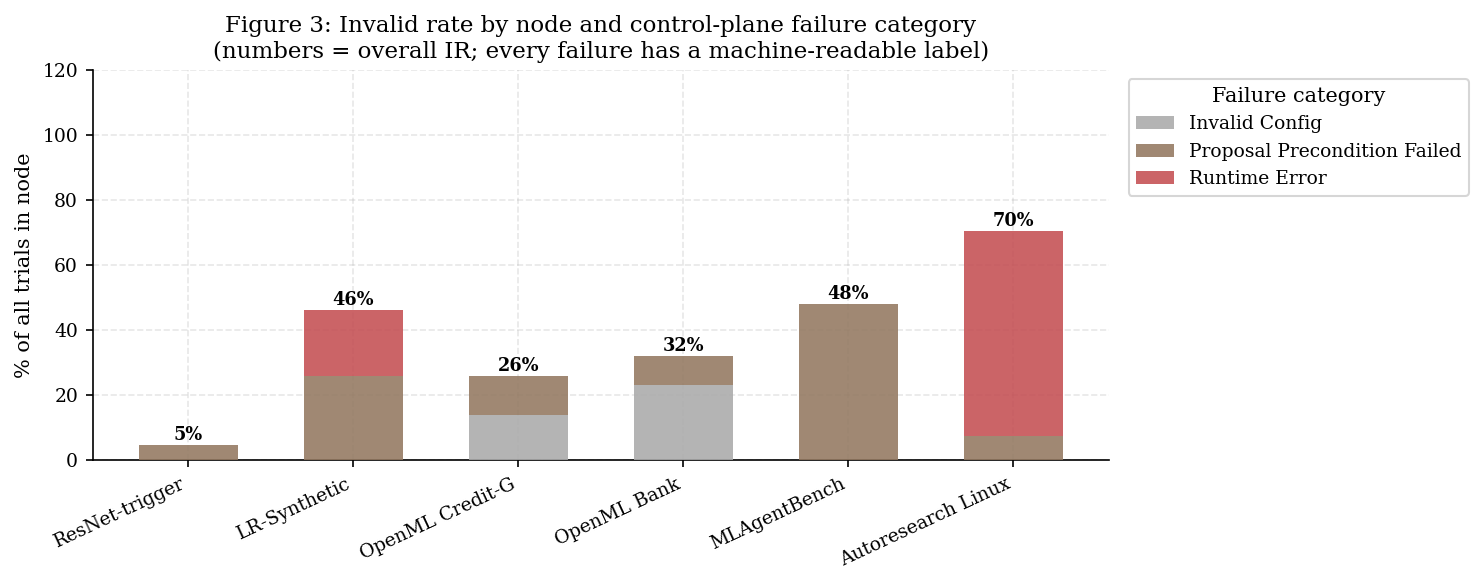

Saved fig3_ir_taxonomy


In [6]:
fail_cats   = defaultdict(lambda: defaultdict(int))
node_totals = defaultdict(int)
for c in ALL_CAMPAIGNS.values():
    node_totals[c["node"]] += c["n"]
    for t in c["failed"]:
        cat = t.get("failure_category") or "unknown"
        fail_cats[c["node"]][cat] += 1

cat_palette = {
    "runtime_error":              "#C44E52",
    "metric_missing":             "#DD8452",
    "proposal_precondition_failed":"#937860",
    "invalid_edit_scope":         "#8172B2",
    "edit_failed":                "#8C8C8C",
    "no_op_patch":                "#CCB974",
    "unknown":                    "#aaa",
}
all_cats = sorted({c for d in fail_cats.values() for c in d})

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(NODE_ORDER))
bottoms = np.zeros(len(NODE_ORDER))
for cat in all_cats:
    vals = [100*fail_cats[n].get(cat, 0)/node_totals[n] for n in NODE_ORDER]
    ax.bar(x, vals, 0.6, bottom=bottoms,
           label=cat.replace("_", " ").title(),
           color=cat_palette.get(cat, "#aaa"), alpha=0.88, zorder=3)
    bottoms += np.array(vals)

for i, node in enumerate(NODE_ORDER):
    ir = 100*sum(fail_cats[node].values())/node_totals[node]
    ax.text(i, ir + 1.5, f"{ir:.0f}%", ha="center", fontsize=8.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([NODE_LABELS[n] for n in NODE_ORDER], rotation=25, ha="right")
ax.set_ylabel("% of all trials in node")
ax.set_ylim(0, 120)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.8,
          title="Failure category")
ax.set_title("Figure 3: Invalid rate by node and control-plane failure category\n"
             "(numbers = overall IR; every failure has a machine-readable label)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig3_ir_taxonomy.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "fig3_ir_taxonomy.svg", bbox_inches="tight")
plt.show(); print("Saved fig3_ir_taxonomy")


## Figure 4 — Trial Decision Timeline (OpenML Bank Marketing s1)

**Status:** Supplement candidate.

Illustrates the control-plane loop: each trial produces exactly one terminal record
(kept / discarded / failed-invalid). The running-best step function advances only when the
control plane keeps a valid improving trial — the keep/discard decision is owned by the
framework, not the manager.


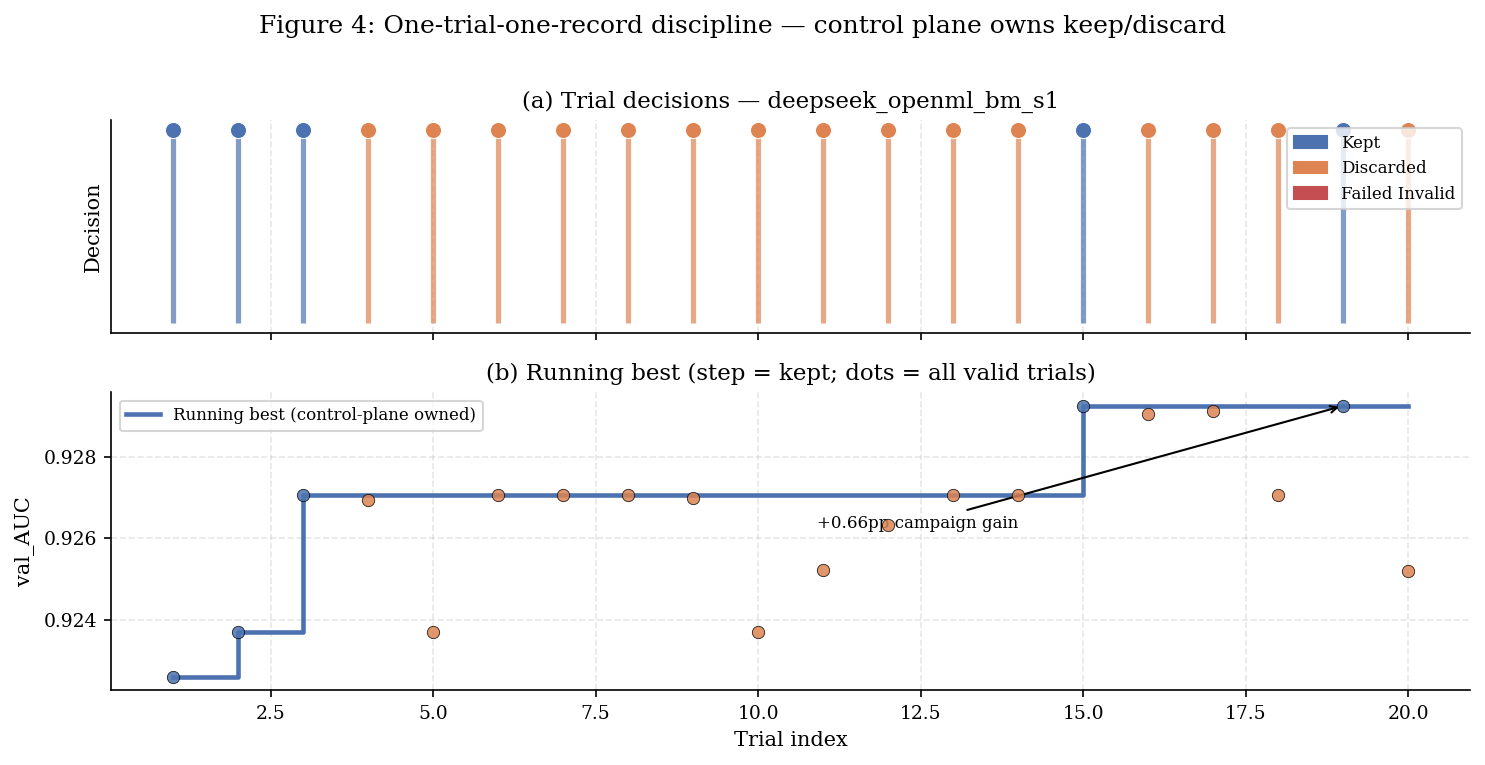

Saved fig4_timeline


In [7]:
cid = "deepseek_openml_bm_s1"
if cid not in ALL_CAMPAIGNS:
    print(f"Campaign {cid} not loaded — skipping fig4")
else:
    rep      = ALL_CAMPAIGNS[cid]
    trials_s = sorted(rep["trials"], key=lambda t: t.get("budget_index", 0))
    indices  = [t.get("budget_index", i+1) for i, t in enumerate(trials_s)]
    decisions= [t.get("decision", "unknown") for t in trials_s]
    metrics  = [get_metric(t) for t in trials_s]

    running_best, cur = [], None
    for t in trials_s:
        m = get_metric(t)
        if t.get("decision") == "kept" and m:
            cur = m
        running_best.append(cur)

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
        gridspec_kw={"height_ratios": [1, 1.4]})

    for idx, dec in zip(indices, decisions):
        clr = dec_colors.get(dec, "#aaa")
        ax_top.vlines(idx, 0, 1, colors=clr, alpha=0.7, linewidth=2.5)
        ax_top.scatter([idx], [1], color=clr, s=60, edgecolors="white", lw=0.5, zorder=3)
    ax_top.set_yticks([])
    ax_top.set_ylabel("Decision")
    ax_top.set_title(f"(a) Trial decisions — {cid}")
    legend_els = [mpatches.Patch(color=dec_colors[d], label=d.replace("_", " ").title())
                  for d in ["kept", "discarded", "failed_invalid"]]
    ax_top.legend(handles=legend_els, loc="upper right", fontsize=8)

    ax_bot.step(indices, running_best, where="post", color=C["kept"], lw=2.2,
                label="Running best (control-plane owned)")
    for idx, dec, m in zip(indices, decisions, metrics):
        if m is not None:
            ax_bot.scatter(idx, m, color=dec_colors.get(dec, "#aaa"), s=35,
                           zorder=4, edgecolors="black", lw=0.4, alpha=0.85)
    ax_bot.set_xlabel("Trial index")
    ax_bot.set_ylabel("val_AUC")
    ax_bot.set_title("(b) Running best (step = kept; dots = all valid trials)")
    ax_bot.legend(fontsize=8)
    kb = [(idx, m) for idx, dec, m in zip(indices, decisions, metrics) if dec == "kept" and m]
    if kb:
        gain = kb[-1][1] - kb[0][1]
        ax_bot.annotate(f"+{gain*100:.2f}pp campaign gain",
            xy=(kb[-1][0], kb[-1][1]), xytext=(kb[-1][0]-5, kb[-1][1]-0.003),
            fontsize=8, ha="right", arrowprops=dict(arrowstyle="->", lw=1))
    fig.suptitle("Figure 4: One-trial-one-record discipline — control plane owns keep/discard", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fig4_timeline.pdf", bbox_inches="tight")
    plt.savefig(FIGURES_DIR / "fig4_timeline.svg", bbox_inches="tight")
    plt.show(); print("Saved fig4_timeline")


## Figure 5 — Cross-Node Acceptance and Invalid Rates

**Status:** Main-paper/supplement candidate.

The same governed contract applies across six task types. AR and IR vary by node and manager
interface; the invariant governance claim is provenance completeness and lifecycle correctness,
not that AR or IR are uniform.


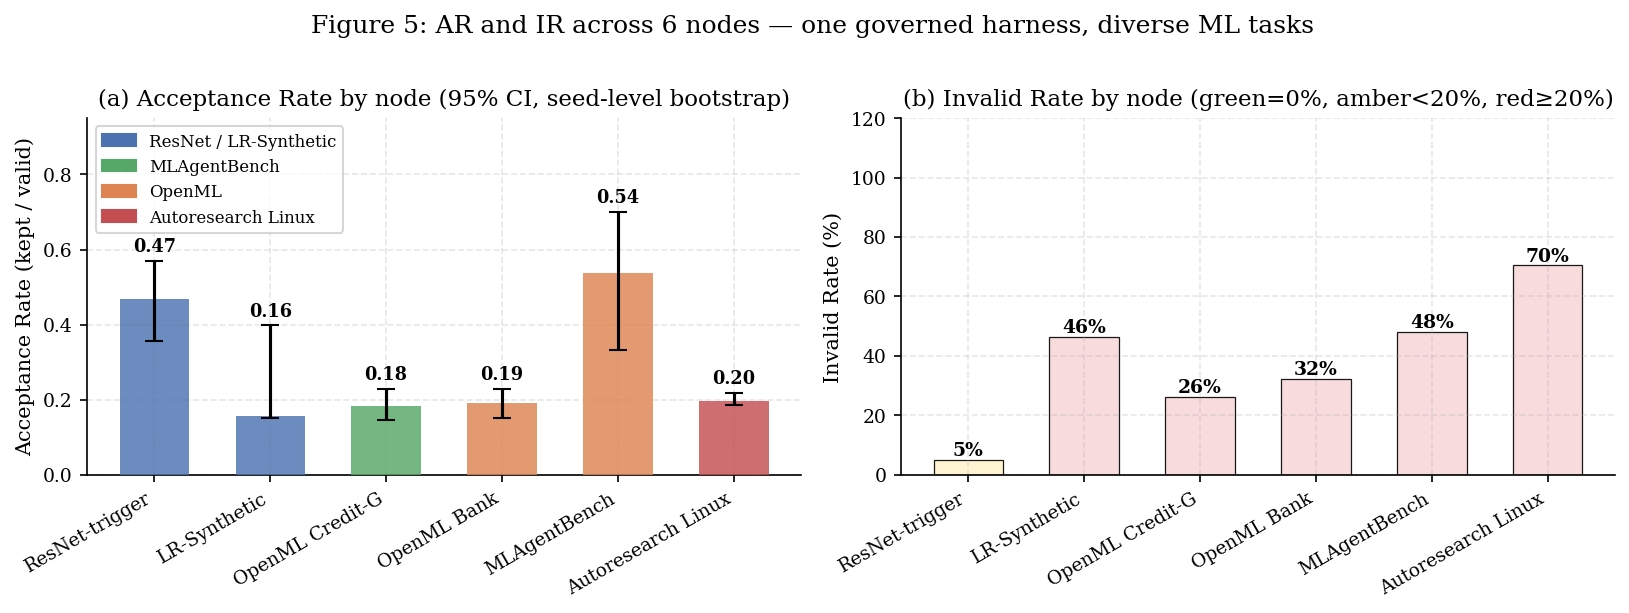

Saved fig5_cross_node


In [8]:
summaries = []
rng_global = np.random.default_rng(42)
for node in NODE_ORDER:
    cs = nodes[node]
    n_all = sum(c["n"]           for c in cs)
    n_kept= sum(len(c["kept"])   for c in cs)
    n_disc= sum(len(c["disc"])   for c in cs)
    n_fail= sum(len(c["failed"]) for c in cs)
    valid = n_kept + n_disc
    ar    = n_kept / valid if valid > 0 else None
    per_seed = [c["ar"] for c in cs if c["ar"] is not None]
    if len(per_seed) >= 2:
        boots   = [np.mean(rng_global.choice(per_seed, len(per_seed), replace=True))
                   for _ in range(10000)]
        ar_lo, ar_hi = np.percentile(boots, [2.5, 97.5])
    elif len(per_seed) == 1:
        ar_lo = ar_hi = per_seed[0]
    else:
        ar_lo = ar_hi = 0
    summaries.append({"node": node, "ar": ar, "ar_lo": ar_lo, "ar_hi": ar_hi,
                      "ir": n_fail/n_all, "n_seeds": len(cs), "n": n_all})

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(NODE_ORDER)); w = 0.6
bar_colors = ["#4C72B0","#4C72B0","#55A868","#DD8452","#DD8452","#C44E52"]
ars    = [s["ar"] or 0  for s in summaries]
ar_los = [s["ar_lo"]    for s in summaries]
ar_his = [s["ar_hi"]    for s in summaries]

ax.bar(x, ars, w, color=bar_colors, alpha=0.82, zorder=3)
ax.errorbar(x, ars, yerr=[np.array(ars)-np.array(ar_los), np.array(ar_his)-np.array(ars)],
    fmt="none", color="black", capsize=4.5, lw=1.5, zorder=4)
for i, s in enumerate(summaries):
    lbl = f"{s['ar']:.2f}" if s["ar"] else "N/A"
    ax.text(i, (s["ar_hi"] or 0)+0.025, lbl, ha="center", fontsize=8.5, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([NODE_LABELS[n] for n in NODE_ORDER], rotation=30, ha="right")
ax.set_ylabel("Acceptance Rate (kept / valid)"); ax.set_ylim(0, 0.95)
ax.set_title("(a) Acceptance Rate by node (95% CI, seed-level bootstrap)")
ax.legend(handles=[
    mpatches.Patch(color="#4C72B0", label="ResNet / LR-Synthetic"),
    mpatches.Patch(color="#55A868", label="MLAgentBench"),
    mpatches.Patch(color="#DD8452", label="OpenML"),
    mpatches.Patch(color="#C44E52", label="Autoresearch Linux"),
], fontsize=8)

irs = [s["ir"] for s in summaries]
ir_colors = ["#d4f0dc" if ir == 0 else "#fff3cd" if ir < 0.2 else "#f8d7da" for ir in irs]
ax2.bar(x, [100*ir for ir in irs], w, color=ir_colors, edgecolor="black", lw=0.6, alpha=0.9)
for i, ir in enumerate(irs):
    ax2.text(i, 100*ir+1.5, f"{100*ir:.0f}%", ha="center", fontsize=9, fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels([NODE_LABELS[n] for n in NODE_ORDER], rotation=30, ha="right")
ax2.set_ylabel("Invalid Rate (%)"); ax2.set_ylim(0, 120)
ax2.set_title("(b) Invalid Rate by node (green=0%, amber<20%, red≥20%)")

fig.suptitle("Figure 5: AR and IR across 6 nodes — one governed harness, diverse ML tasks", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig5_cross_node.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "fig5_cross_node.svg", bbox_inches="tight")
plt.show(); print("Saved fig5_cross_node")


## Figure 6 — Provenance and Artifact Completeness

**Status:** Supplement candidate.

Supports the audit-trail claim. Every trial has a complete provenance chain
(proposal → patch → run → metric → decision). Patch and metric availability vary
by lifecycle path: precondition failures produce no patch diff because the worker
is never invoked; runtime errors produce a log but no parsed metric.


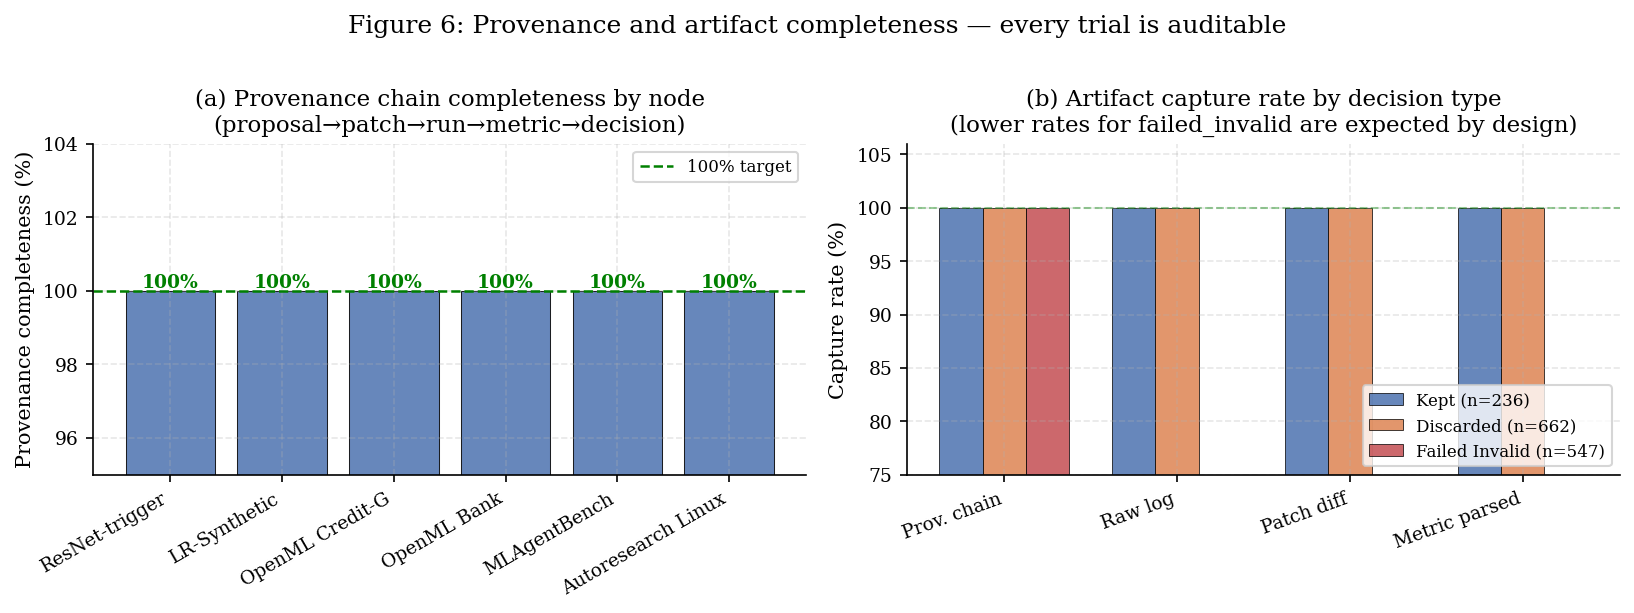

Saved fig6_provenance


In [9]:
prov_rows = []
for cid, c in ALL_CAMPAIGNS.items():
    for t in c["trials"]:
        prov = t.get("provenance", {})
        prov_rows.append({
            "node":      c["node"],
            "decision":  t.get("decision", "unknown"),
            "has_prov":  bool(prov and prov.get("proposal_id") and prov.get("decision_id")),
            "has_log":   bool(t.get("raw_log_ref")),
            "has_patch": bool(t.get("patch_ref")),
            "has_metric":bool(t.get("parsed_metrics")),
        })
df_prov = pd.DataFrame(prov_rows)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4))

np_ = (df_prov.groupby("node")["has_prov"]
       .agg(["sum", "count"]).reset_index())
np_["rate"]  = 100 * np_["sum"] / np_["count"]
np_["order"] = np_["node"].map({n: i for i, n in enumerate(NODE_ORDER)})
np_ = np_.sort_values("order").dropna(subset=["order"]).reset_index(drop=True)

bars = ax.bar(range(len(np_)), np_["rate"], color="#4C72B0", alpha=0.85, edgecolor="black", lw=0.5)
for i, row in np_.iterrows():
    ax.text(i, row["rate"] + 0.1, f"{row['rate']:.0f}%",
            ha="center", fontsize=9, fontweight="bold",
            color="green" if row["rate"] == 100 else "red")
ax.set_xticks(range(len(np_)))
ax.set_xticklabels([NODE_LABELS[n] for n in np_["node"].tolist()], rotation=30, ha="right")
ax.set_ylabel("Provenance completeness (%)")
ax.set_ylim(95, 104)
ax.axhline(100, color="green", linestyle="--", lw=1.2, label="100% target")
ax.legend(fontsize=8)
ax.set_title("(a) Provenance chain completeness by node\n(proposal→patch→run→metric→decision)")

decs      = ["kept", "discarded", "failed_invalid"]
dec_bcolors = [C["kept"], C["discarded"], C["failed"]]
fields    = ["has_prov", "has_log", "has_patch", "has_metric"]
flabels   = ["Prov. chain", "Raw log", "Patch diff", "Metric parsed"]
x2        = np.arange(len(fields))
offsets   = [-0.25, 0, 0.25]; w2 = 0.25

for_dec = df_prov.groupby("decision").agg(
    n=("has_prov","count"), **{f: (f,"mean") for f in fields}).reset_index()

for dec, clr, off in zip(decs, dec_bcolors, offsets):
    row = for_dec[for_dec["decision"] == dec]
    if row.empty: continue
    vals = [float(row[f].values[0])*100 for f in fields]
    n    = int(row["n"].values[0])
    ax2.bar(x2+off, vals, w2, color=clr, alpha=0.85,
            label=f"{dec.replace('_',' ').title()} (n={n})", edgecolor="black", lw=0.4)
ax2.set_xticks(x2); ax2.set_xticklabels(flabels, rotation=20, ha="right")
ax2.set_ylabel("Capture rate (%)"); ax2.set_ylim(75, 106)
ax2.legend(fontsize=8, framealpha=0.8)
ax2.axhline(100, color="green", linestyle="--", lw=1, alpha=0.4)
ax2.set_title("(b) Artifact capture rate by decision type\n(lower rates for failed_invalid are expected by design)")

fig.suptitle("Figure 6: Provenance and artifact completeness — every trial is auditable", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig6_provenance.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "fig6_provenance.svg", bbox_inches="tight")
plt.show(); print("Saved fig6_provenance")


## Figure 7 — OpenML Best-Metric Trajectories

**Status:** Supplement candidate.

Shows governed keep/discard behaviour on two public tabular nodes. Running-best is
monotonically non-decreasing because the control plane accepts only improving valid trials.
The mean trajectory (red) and individual-seed lines (blue, thin) show variance across seeds.


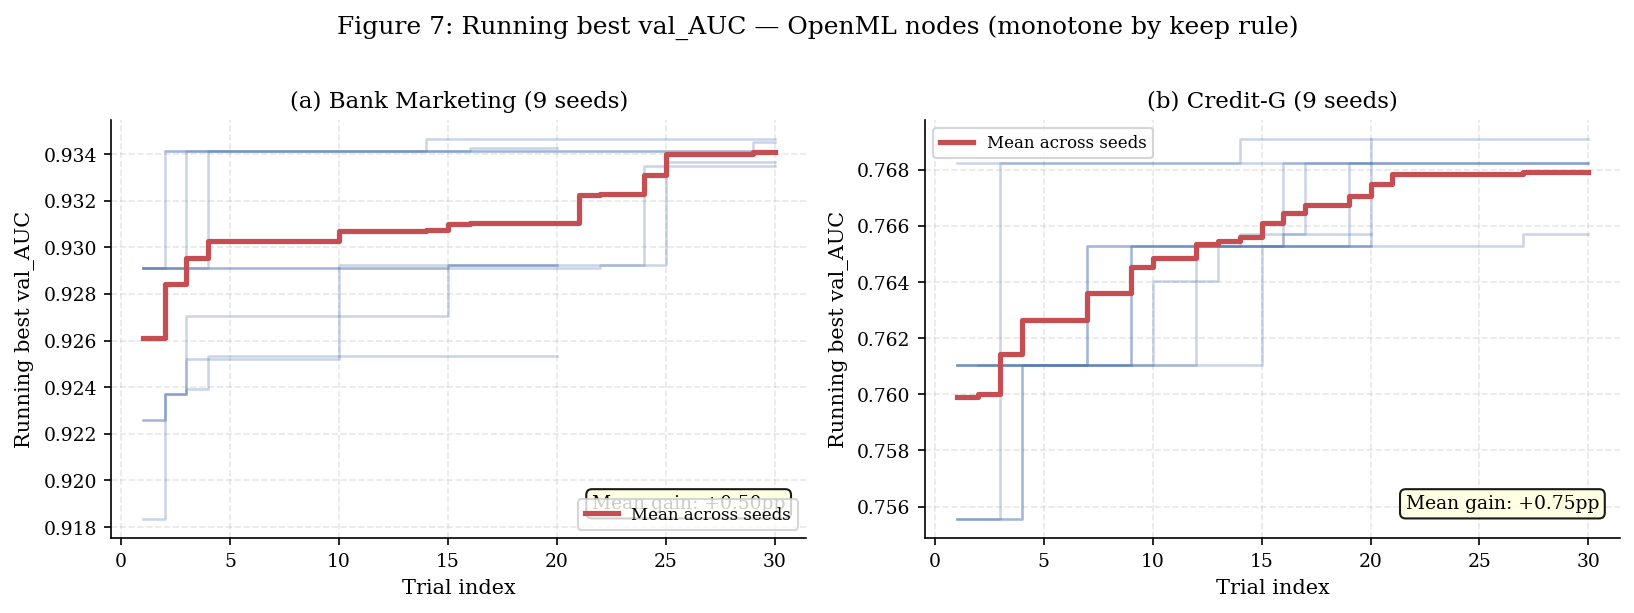

Saved fig7_openml


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax_i, (ds_node, ds_label) in enumerate([
        ("openml_bm", "Bank Marketing"), ("openml_cg", "Credit-G")]):
    ax = axes[ax_i]
    ds_cs = [c for c in ALL_CAMPAIGNS.values() if c["node"] == ds_node]
    all_trajs = []
    for c in ds_cs:
        ts  = sorted(c["trials"], key=lambda t: t.get("budget_index", 0))
        rb, cur = [], None
        for t in ts:
            m = get_metric(t)
            if t.get("decision") == "kept" and m:
                cur = m
            rb.append(cur)
        idx = [t.get("budget_index", i+1) for i, t in enumerate(ts)]
        valid_pts = [(i, v) for i, v in zip(idx, rb) if v is not None]
        if valid_pts:
            xi, yi = zip(*valid_pts)
            ax.step(xi, yi, where="post", alpha=0.3, lw=1.2, color="#4C72B0")
        all_trajs.append((idx, rb))
    max_idx = max(max(i) for i, _ in all_trajs)
    means = []
    for ti in range(1, max_idx+1):
        vs = [rb[idx.index(ti)] for idx, rb in all_trajs
              if ti in idx and rb[idx.index(ti)] is not None]
        means.append(np.mean(vs) if vs else None)
    valid_means = [(i+1, v) for i, v in enumerate(means) if v is not None]
    if valid_means:
        xi, yi = zip(*valid_means)
        ax.step(xi, yi, where="post", color="#C44E52", lw=2.5, label="Mean across seeds", zorder=5)
    lasts  = [rb[-1] for _, rb in all_trajs if rb[-1] is not None]
    firsts = [next((v for v in rb if v is not None), None) for _, rb in all_trajs]
    firsts = [f for f in firsts if f is not None]
    if firsts and lasts:
        gain = np.mean(lasts) - np.mean(firsts)
        ax.annotate(f"Mean gain: +{gain*100:.2f}pp",
            xy=(0.97, 0.07), xycoords="axes fraction", ha="right", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.9))
    ax.set_xlabel("Trial index"); ax.set_ylabel("Running best val_AUC")
    ax.set_title(f"({chr(97+ax_i)}) {ds_label} ({len(ds_cs)} seeds)")
    ax.legend(fontsize=8)

fig.suptitle("Figure 7: Running best val_AUC — OpenML nodes (monotone by keep rule)", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig7_openml.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "fig7_openml.svg", bbox_inches="tight")
plt.show(); print("Saved fig7_openml")


## Table 1 — Paper-Facing Governance Summary

Exports the per-node governance summary CSV used as a cross-check against paper tables.
All numbers should match the main paper's cross-node summary table.


In [11]:
summary_rows = []
rng_t = np.random.default_rng(42)
for node in NODE_ORDER:
    cs     = nodes[node]
    n_all  = sum(c["n"]           for c in cs)
    n_kept = sum(len(c["kept"])   for c in cs)
    n_disc = sum(len(c["disc"])   for c in cs)
    n_fail = sum(len(c["failed"]) for c in cs)
    valid  = n_kept + n_disc
    ar     = n_kept / valid if valid > 0 else None
    per_seed = [c["ar"] for c in cs if c["ar"] is not None]
    if len(per_seed) >= 2:
        boots   = [np.mean(rng_t.choice(per_seed, len(per_seed), replace=True))
                   for _ in range(10000)]
        lo, hi  = np.percentile(boots, [2.5, 97.5])
        ci_str  = f"[{lo:.2f},{hi:.2f}]"
    elif len(per_seed) == 1:
        ci_str = "--"
    else:
        ci_str = "--"
    bests = [get_metric(t) for c in cs for t in c["kept"] if get_metric(t) is not None]
    n_prov = sum(sum(1 for t in c["trials"]
                     if t.get("provenance") and t["provenance"].get("proposal_id"))
                 for c in cs)
    summary_rows.append({
        "Node":      NODE_LABELS[node],
        "Seeds":     len(cs),
        "Trials":    n_all,
        "AR":        f"{ar:.3f}" if ar else "N/A",
        "95% CI":    ci_str,
        "IR":        f"{100*n_fail/n_all:.1f}%",
        "Best metric": f"{max(bests):.4f}" if bests else "N/A",
        "Prov. 100%": "Yes" if n_prov == n_all else f"{n_prov}/{n_all}",
    })

df_tbl = pd.DataFrame(summary_rows)
df_tbl.to_csv(TABLES_DIR / "table1_governance_summary.csv", index=False)
print("Saved table1_governance_summary.csv")
print()
print(df_tbl.to_string(index=False))


Saved table1_governance_summary.csv

              Node  Seeds  Trials    AR      95% CI    IR Best metric Prov. 100%
    ResNet-trigger     16     245 0.468 [0.36,0.57]  4.9%      0.9435        Yes
      LR-Synthetic     15     450 0.157 [0.15,0.40] 46.2%      0.9230        Yes
   OpenML Credit-G      9     230 0.182 [0.15,0.23] 26.1%      0.7691        Yes
       OpenML Bank      9     230 0.192 [0.15,0.23] 32.2%      0.9347        Yes
      MLAgentBench      3      50 0.538 [0.33,0.70] 48.0%         N/A        Yes
Autoresearch Linux      8     240 0.197 [0.19,0.22] 70.4%         N/A        Yes


## Figure 9 — ResNet L40S Memory Diagnostic (5 Clean Seeds)

**Status:** Paper figure — final, clean 5-seed verified.

All five seeds use a verified clean reset (`node_state_hash = 9c0118f33fcb` at trial 1
across all 15 campaigns). The left panel shows per-seed acceptance and invalid rates
by memory arm; the right panel shows per-seed best AUC with the mean marked as a diamond.

**Key finding:** none < summary ≈ rationale in mean AUC (0.899 < 0.938 < 0.941),
with 4–5× variance reduction (σ_none = 0.009 vs σ_summary = σ_rationale = 0.002).
This is a node- and manager-specific diagnostic result, not a general claim.


In [12]:
ARMS_LIN = ["none", "append_only_summary", "append_only_summary_with_rationale"]
ARM_LABELS_LIN = {
    "none":                               "No Memory",
    "append_only_summary":                "Summary",
    "append_only_summary_with_rationale": "Summary+Rationale",
}
# All 5 clean seeds — verified reset discipline
SEEDS_LIN = ["s1", "s2", "s3", "s4", "s5"]

resnet_linux = {}
for arm in ARMS_LIN:
    resnet_linux[arm] = {}
    for seed in SEEDS_LIN:
        path   = LEDGER_DIR / f"deepseek_resnet_{arm}_{seed}_trials.jsonl"
        trials = [json.loads(l) for l in open(path) if l.strip()]
        kept   = [t for t in trials if t.get("decision") == "kept"]
        inv    = [t for t in trials if t.get("decision") == "failed_invalid"]
        disc   = [t for t in trials if t.get("decision") == "discarded"]
        bests  = [float(t["parsed_metrics"]["val_auc"])
                  for t in kept if "val_auc" in t.get("parsed_metrics", {})]
        cur_best, traj = None, []
        for t in sorted(trials, key=lambda x: x.get("budget_index", 0)):
            mv = t.get("parsed_metrics", {}).get("val_auc")
            if mv is not None and t.get("decision") == "kept":
                cur_best = max(cur_best or 0, float(mv))
            traj.append((t.get("budget_index", 0), cur_best))
        resnet_linux[arm][seed] = {
            "trials": trials, "kept_n": len(kept), "inv_n": len(inv),
            "disc_n": len(disc), "n": len(trials),
            "best_auc": max(bests) if bests else None, "trajectory": traj,
        }

print("ResNet L40S — 5 clean seeds:")
print(f"  {'Arm':<28}  {'Mean AUC':>9}  {'σ':>6}  {'Acc%':>6}  Per-seed best AUCs")
for arm in ARMS_LIN:
    bests  = [resnet_linux[arm][s]["best_auc"] for s in SEEDS_LIN if resnet_linux[arm][s]["best_auc"]]
    mean_b = np.mean(bests); std_b = np.std(bests)
    accs   = [resnet_linux[arm][s]["kept_n"] / resnet_linux[arm][s]["n"] for s in SEEDS_LIN]
    print(f"  {ARM_LABELS_LIN[arm]:<28}  {mean_b:>9.4f}  {std_b:>6.4f}  {np.mean(accs)*100:>6.1f}%  "
          f"{[round(b,4) for b in bests]}")


ResNet L40S — 5 clean seeds:
  Arm                            Mean AUC       σ    Acc%  Per-seed best AUCs
  No Memory                        0.8993  0.0086    17.3%  [0.9121, 0.8891, 0.895, 0.9064, 0.8937]
  Summary                          0.9385  0.0016    64.0%  [0.9385, 0.9374, 0.9372, 0.938, 0.9415]
  Summary+Rationale                0.9413  0.0020    58.7%  [0.9398, 0.9432, 0.9415, 0.9435, 0.9383]


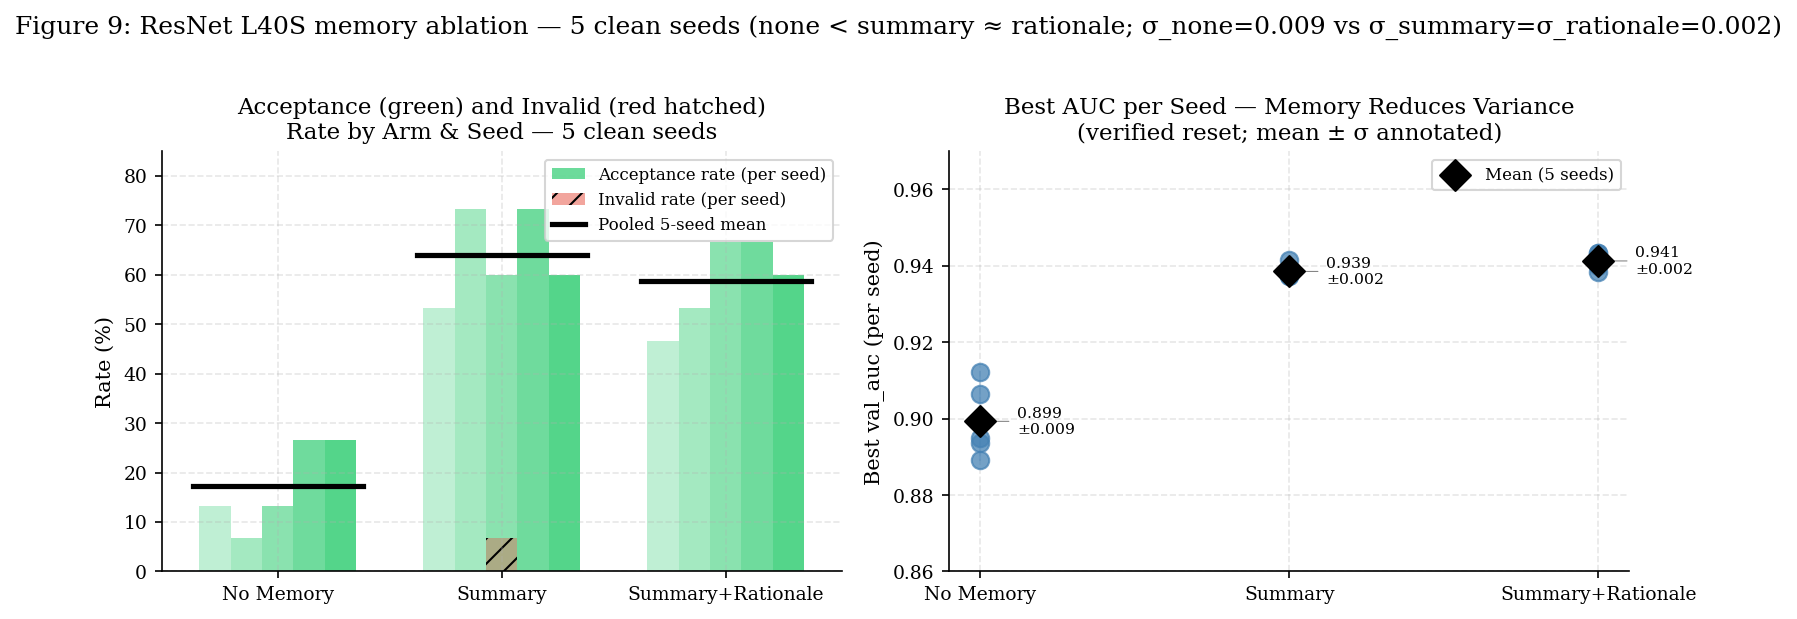

Saved fig9_resnet_linux_ablation (5 clean seeds)


In [13]:
n_seeds = len(SEEDS_LIN)
w_bar   = 0.14   # bar width per seed

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: per-seed acceptance & invalid rates ─────────────────────────────────
ax = axes[0]
x  = np.arange(len(ARMS_LIN))
for si, seed in enumerate(SEEDS_LIN):
    offset = (si - (n_seeds-1)/2) * w_bar
    accs = [resnet_linux[arm][seed]["kept_n"] / resnet_linux[arm][seed]["n"] * 100
            for arm in ARMS_LIN]
    invs = [resnet_linux[arm][seed]["inv_n"]  / resnet_linux[arm][seed]["n"] * 100
            for arm in ARMS_LIN]
    alpha_a = 0.30 + si * 0.13
    ax.bar(x + offset, accs, w_bar, color="#2ecc71", alpha=alpha_a)
    ax.bar(x + offset, invs, w_bar, color="#e74c3c", alpha=0.22 + si*0.07, hatch="//")

# Pooled 5-seed mean lines
for ai, arm in enumerate(ARMS_LIN):
    mean_acc = np.mean([resnet_linux[arm][s]["kept_n"] / resnet_linux[arm][s]["n"]
                        for s in SEEDS_LIN]) * 100
    ax.plot([ai - n_seeds*w_bar/2 - 0.03, ai + n_seeds*w_bar/2 + 0.03],
            [mean_acc, mean_acc], "k-", lw=2.5, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([ARM_LABELS_LIN[a] for a in ARMS_LIN], fontsize=9)
ax.set_ylabel("Rate (%)")
ax.set_ylim(0, 85)
ax.set_title("Acceptance (green) and Invalid (red hatched)\nRate by Arm & Seed — 5 clean seeds")
ax.legend(handles=[
    mpatches.Patch(facecolor="#2ecc71", alpha=0.7, label="Acceptance rate (per seed)"),
    mpatches.Patch(facecolor="#e74c3c", alpha=0.5, hatch="//", label="Invalid rate (per seed)"),
    plt.Line2D([0], [0], color="black", lw=2.5, label="Pooled 5-seed mean"),
], fontsize=8, loc="upper right")

# ── Right: best AUC per seed (dot plot with σ annotation) ────────────────────
ax2 = axes[1]
for ai, arm in enumerate(ARMS_LIN):
    bests   = [resnet_linux[arm][s]["best_auc"] for s in SEEDS_LIN if resnet_linux[arm][s]["best_auc"]]
    mean_b  = np.mean(bests)
    std_b   = np.std(bests)
    # dots per seed
    for b in bests:
        ax2.scatter(ai, b, color="steelblue", s=70, zorder=3, alpha=0.75)
    # mean diamond
    ax2.scatter(ai, mean_b, color="black", marker="D", s=110, zorder=4,
                label="Mean (5 seeds)" if ai == 0 else "")
    # vertical spread line
    ax2.plot([ai]*len(bests), bests, color="steelblue", alpha=0.25, lw=1)
    # annotate mean ± σ
    ax2.annotate(f"{mean_b:.3f}\n±{std_b:.3f}",
                 xy=(ai, mean_b), xytext=(ai + 0.12, mean_b),
                 fontsize=7.5, va="center",
                 arrowprops=dict(arrowstyle="-", lw=0.5, color="grey"))

ax2.set_xticks(range(len(ARMS_LIN)))
ax2.set_xticklabels([ARM_LABELS_LIN[a] for a in ARMS_LIN], fontsize=9)
ax2.set_ylabel("Best val_auc (per seed)")
ax2.set_title("Best AUC per Seed — Memory Reduces Variance\n(verified reset; mean ± σ annotated)")
ax2.set_ylim(0.86, 0.97)
ax2.legend(fontsize=8)

fig.suptitle(
    "Figure 9: ResNet L40S memory ablation — 5 clean seeds "
    "(none < summary ≈ rationale; σ_none=0.009 vs σ_summary=σ_rationale=0.002)",
    y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig9_resnet_linux_ablation.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "fig9_resnet_linux_ablation.svg", bbox_inches="tight")
plt.show(); print("Saved fig9_resnet_linux_ablation (5 clean seeds)")


## Figure 10 — ResNet L40S Best-AUC Trajectory by Memory Mode

**Status:** Supplement candidate.

Shows how the running best AUC evolves across 15 trials per seed. Thin lines are individual
seeds; thick lines are the 5-seed mean. The separation between arms is visible by trial 3–5,
consistent with the memory context improving proposal quality early in the campaign.


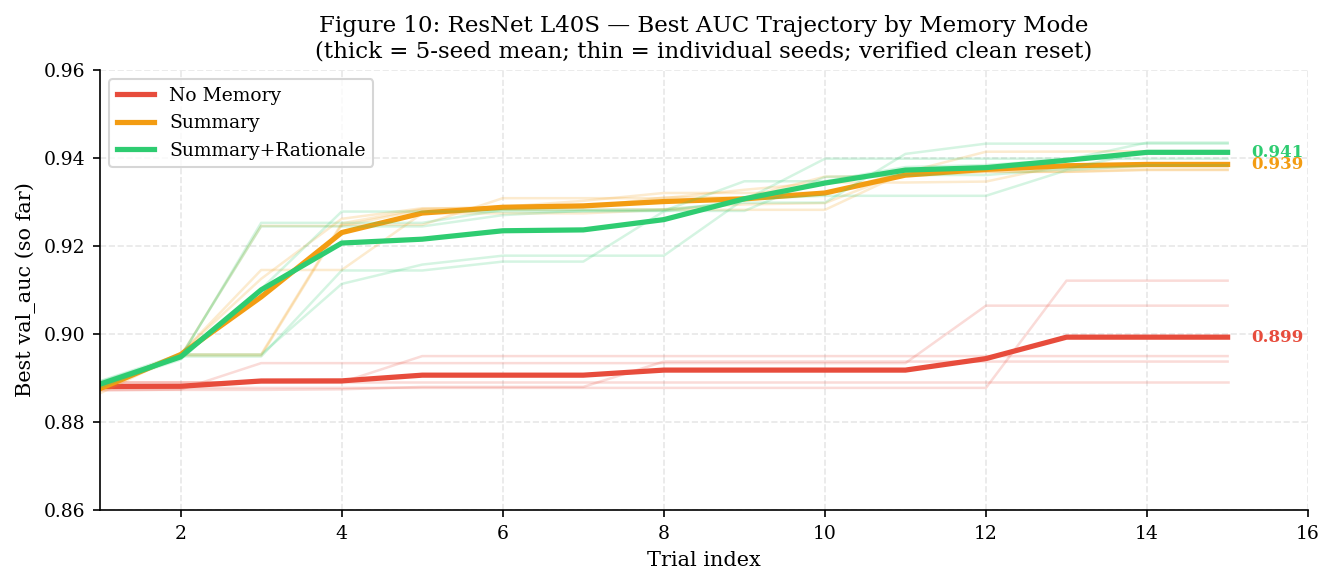

Saved fig10_resnet_linux_trajectory (5 clean seeds)


In [14]:
arm_colors10 = {
    "none":                               "#e74c3c",
    "append_only_summary":                "#f39c12",
    "append_only_summary_with_rationale": "#2ecc71",
}

fig, ax = plt.subplots(figsize=(9, 4))
for arm in ARMS_LIN:
    color     = arm_colors10[arm]
    label     = ARM_LABELS_LIN[arm]
    all_trajs = []
    for seed in SEEDS_LIN:
        traj   = resnet_linux[arm][seed]["trajectory"]
        filled = []
        last   = None
        for _, v in traj:
            if v is not None: last = v
            filled.append(last or 0.0)
        ax.plot(range(1, len(filled)+1), filled, color=color, alpha=0.2, lw=1.2)
        all_trajs.append(filled)
    mean_traj = [np.mean([t[i] for t in all_trajs]) for i in range(len(all_trajs[0]))]
    ax.plot(range(1, len(mean_traj)+1), mean_traj, color=color, lw=2.5, label=label)
    # Annotate final mean
    ax.annotate(f"{mean_traj[-1]:.3f}",
                xy=(len(mean_traj), mean_traj[-1]),
                xytext=(len(mean_traj)+0.3, mean_traj[-1]),
                fontsize=8, va="center", color=color, fontweight="bold")

ax.set_xlabel("Trial index"); ax.set_ylabel("Best val_auc (so far)")
ax.set_title("Figure 10: ResNet L40S — Best AUC Trajectory by Memory Mode\n"
             "(thick = 5-seed mean; thin = individual seeds; verified clean reset)")
ax.legend(fontsize=9)
ax.set_xlim(1, 16); ax.set_ylim(0.86, 0.96)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig10_resnet_linux_trajectory.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "fig10_resnet_linux_trajectory.svg", bbox_inches="tight")
plt.show(); print("Saved fig10_resnet_linux_trajectory (5 clean seeds)")


## Figure 8 — Retired MLP Ablation

**Status:** Retired / exploratory. Not in the six-node evidence set.
Cell runs but produces no output unless MLP ledgers are present.


In [15]:
mlp_cs = [c for c in ALL_CAMPAIGNS.values() if c["node"] == "mlp_synthetic"]
if not mlp_cs:
    print("MLP synthetic excluded from six-node evidence set — no figure generated.")


MLP synthetic excluded from six-node evidence set — no figure generated.


## Figure 11 — Counterfactual: Governed vs. Ungoverned Ledger Completeness

**Status:** Main-paper figure — §5 Stress Campaigns and Ungoverned Counterfactual.

Two matched governed/ungoverned arms on:
- `autoresearch_linux` N=30, IR=100% — ungoverned ledger completely empty
- `openml_bank_marketing` N=20, IR=55% — ungoverned ledger retains only 7/20 trials

Combined: 43/50 (86%) ungoverned trials silently absent vs. 0/50 governed.
95% bootstrap CIs: 10,000 resamples, seed 42.

=== autoresearch_linux (N=30) ===
  governed:   kept=0 disc=0 failed_inv=30 (runtime_error)
  gov  completeness=1.00  CI=[1.00,1.00]
  ung  completeness=0.00  CI=[0.00,0.00]  drops=30

=== openml_bank_marketing (N=20) ===
  governed:   kept=6 disc=3 failed_inv=11 (invalid_config)
  ungov ledger: kept=5 disc=2 failed_inv=0 (silently dropped)
  gov  completeness=1.00  CI=[1.00,1.00]
  ung  completeness=0.35  CI=[0.15,0.55]  drops=13

Combined: 43/50 ungoverned trials (86%) silently absent
Governed: 0/50 absent (100% completeness by structural invariant)

Figure saved → /Users/wongdowling/Documents/autoresearch_harness/A-Governed-Harness-for-Auditable-LLM-Driven-ML-Experimentation/figures/fig11_counterfactual.pdf


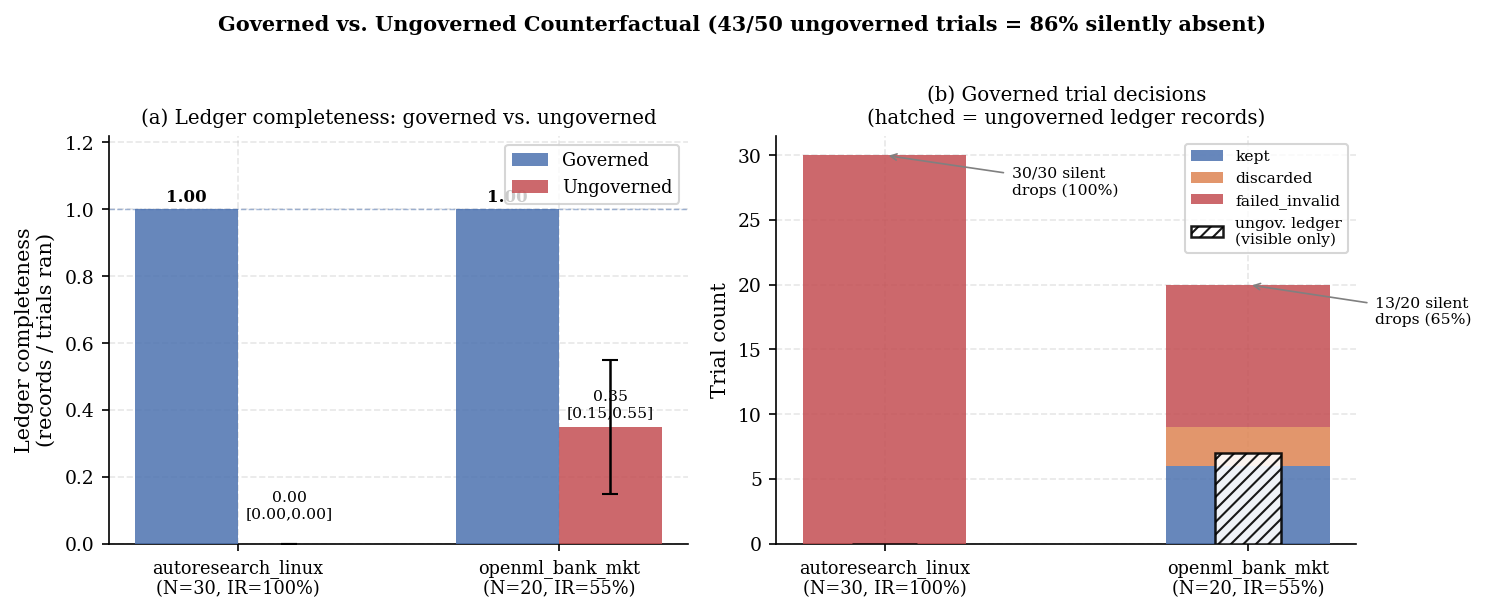

In [16]:
# ── Load counterfactual ledgers ───────────────────────────────────────────────
def load_obs_log(path):
    entries = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                try: entries.append(json.loads(line))
                except json.JSONDecodeError: pass
    return entries

def bootstrap_ci_completeness(vec, n=10_000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    arr = np.array(vec, dtype=float)
    if len(arr) == 0: return 0.0, 0.0
    means = [rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n)]
    alpha = (1 - ci) / 2
    return float(np.percentile(means, 100 * alpha)), float(np.percentile(means, 100 * (1 - alpha)))

# ── autoresearch_linux ────────────────────────────────────────────────────────
ar_gov_path  = LEDGER_DIR / "kdd_cf_arlinux_gov_trials.jsonl"
ar_obs_path  = LEDGER_DIR / "kdd_cf_arlinux_ung_ungoverned_obs.jsonl"

ar_gov_recs  = load_ledger(ar_gov_path)  if ar_gov_path.exists() else []
ar_obs       = load_obs_log(ar_obs_path) if ar_obs_path.exists() else []

ar_n         = len(ar_gov_recs)
ar_kept      = sum(1 for r in ar_gov_recs if r["decision"] == "kept")
ar_disc      = sum(1 for r in ar_gov_recs if r["decision"] == "discarded")
ar_fail      = sum(1 for r in ar_gov_recs if r["decision"] == "failed_invalid")
ar_fail_cat  = ar_gov_recs[0].get("failure_category","?") if ar_gov_recs else "?"

ar_ung_vec   = [1.0 if e.get("ungoverned_ledger_entry") else 0.0 for e in ar_obs]
ar_ung_comp  = sum(ar_ung_vec) / len(ar_ung_vec) if ar_ung_vec else 0.0
ar_gov_ci    = (1.0, 1.0)
ar_ung_ci    = bootstrap_ci_completeness(ar_ung_vec)
ar_drops     = sum(1 for x in ar_ung_vec if x == 0.0)

# ── openml_bank_marketing ────────────────────────────────────────────────────
om_gov_path  = LEDGER_DIR / "kdd_cf_openml_gov_trials.jsonl"
om_ung_path  = LEDGER_DIR / "kdd_cf_openml_ung_trials.jsonl"
om_obs_path  = LEDGER_DIR / "kdd_cf_openml_ung_ungoverned_obs.jsonl"

om_gov_recs  = load_ledger(om_gov_path)  if om_gov_path.exists() else []
om_ung_recs  = load_ledger(om_ung_path)  if om_ung_path.exists() else []
om_obs       = load_obs_log(om_obs_path) if om_obs_path.exists() else []

om_n         = len(om_gov_recs)
om_kept      = sum(1 for r in om_gov_recs if r["decision"] == "kept")
om_disc      = sum(1 for r in om_gov_recs if r["decision"] == "discarded")
om_fail      = sum(1 for r in om_gov_recs if r["decision"] == "failed_invalid")
om_fail_cat  = next((r.get("failure_category","?") for r in om_gov_recs
                     if r["decision"]=="failed_invalid"), "?")
om_ung_kept  = sum(1 for r in om_ung_recs if r["decision"] == "kept")
om_ung_disc  = sum(1 for r in om_ung_recs if r["decision"] == "discarded")

om_ung_vec   = [1.0 if e.get("ungoverned_ledger_entry") else 0.0 for e in om_obs]
om_ung_comp  = sum(om_ung_vec) / len(om_ung_vec) if om_ung_vec else 0.0
om_gov_ci    = (1.0, 1.0)
om_ung_ci    = bootstrap_ci_completeness(om_ung_vec)
om_drops     = sum(1 for x in om_ung_vec if x == 0.0)

# ── Print summary ─────────────────────────────────────────────────────────────
print("=== autoresearch_linux (N={}) ===".format(ar_n))
print(f"  governed:   kept={ar_kept} disc={ar_disc} failed_inv={ar_fail} ({ar_fail_cat})")
print(f"  gov  completeness=1.00  CI=[{ar_gov_ci[0]:.2f},{ar_gov_ci[1]:.2f}]")
print(f"  ung  completeness={ar_ung_comp:.2f}  CI=[{ar_ung_ci[0]:.2f},{ar_ung_ci[1]:.2f}]  drops={ar_drops}")
print()
print("=== openml_bank_marketing (N={}) ===".format(om_n))
print(f"  governed:   kept={om_kept} disc={om_disc} failed_inv={om_fail} ({om_fail_cat})")
print(f"  ungov ledger: kept={om_ung_kept} disc={om_ung_disc} failed_inv=0 (silently dropped)")
print(f"  gov  completeness=1.00  CI=[{om_gov_ci[0]:.2f},{om_gov_ci[1]:.2f}]")
print(f"  ung  completeness={om_ung_comp:.2f}  CI=[{om_ung_ci[0]:.2f},{om_ung_ci[1]:.2f}]  drops={om_drops}")
print()
total_drops = ar_drops + om_drops
total_trials_cf = ar_n + om_n
print(f"Combined: {total_drops}/{total_trials_cf} ungoverned trials ({total_drops/total_trials_cf*100:.0f}%) silently absent")
print(f"Governed: 0/{total_trials_cf} absent (100% completeness by structural invariant)")

# ── Figure 11 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

NODE_CF = [
    ("autoresearch_linux", f"autoresearch_linux\n(N={ar_n}, IR=100%)",
     ar_ung_comp, ar_ung_ci, ar_drops, ar_n, ar_kept, ar_disc, ar_fail),
    ("openml_bank_mkt",    f"openml_bank_mkt\n(N={om_n}, IR=55%)",
     om_ung_comp, om_ung_ci, om_drops, om_n, om_kept, om_disc, om_fail),
]

# ── Left panel: completeness bars ────────────────────────────────────────────
ax = axes[0]
x      = np.arange(len(NODE_CF))
w      = 0.32
col_gov = "#4C72B0"
col_ung = "#C44E52"

gov_vals = [1.0, 1.0]
ung_vals = [r[2] for r in NODE_CF]
ung_cis  = [r[3] for r in NODE_CF]

bars_gov = ax.bar(x - w/2, gov_vals, w, label="Governed",   color=col_gov, alpha=0.85, zorder=3)
bars_ung = ax.bar(x + w/2, ung_vals, w, label="Ungoverned", color=col_ung, alpha=0.85, zorder=3)

# CI error bars on ungoverned only
ung_lo = [v - ci[0] for v, ci in zip(ung_vals, ung_cis)]
ung_hi = [ci[1] - v for v, ci in zip(ung_vals, ung_cis)]
ax.errorbar(x + w/2, ung_vals,
            yerr=[ung_lo, ung_hi],
            fmt='none', color='black', capsize=4, linewidth=1.2, zorder=4)

# Value labels
for bar, v in zip(bars_gov, gov_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, "1.00",
            ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar, v, ci in zip(bars_ung, ung_vals, ung_cis):
    label = f"{v:.2f}\n[{ci[0]:.2f},{ci[1]:.2f}]"
    ax.text(bar.get_x() + bar.get_width()/2,
            max(v, 0.05) + 0.02, label,
            ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels([r[1] for r in NODE_CF], fontsize=8.5)
ax.set_ylabel("Ledger completeness\n(records / trials ran)")
ax.set_ylim(0, 1.22)
ax.set_title("(a) Ledger completeness: governed vs. ungoverned", fontsize=9.5)
ax.legend(fontsize=8.5)
ax.axhline(1.0, color=col_gov, linewidth=0.7, linestyle='--', alpha=0.5)

# ── Right panel: stacked decision breakdown (governed arm) ────────────────────
ax2 = axes[1]
node_labels = [r[1] for r in NODE_CF]
kept_v  = [r[6] for r in NODE_CF]
disc_v  = [r[7] for r in NODE_CF]
fail_v  = [r[8] for r in NODE_CF]
n_vals  = [r[5] for r in NODE_CF]

# Stacked bars for governed (actual decisions)
b1 = ax2.bar(x, kept_v,  0.45, label="kept",          color=C["kept"],      alpha=0.85, zorder=3)
b2 = ax2.bar(x, disc_v,  0.45, bottom=kept_v,         label="discarded",    color=C["discarded"], alpha=0.85, zorder=3)
b3 = ax2.bar(x, fail_v,  0.45,
             bottom=[k+d for k,d in zip(kept_v, disc_v)],
             label="failed_invalid", color=C["failed"], alpha=0.85, zorder=3)

# Overlay: ungoverned visible records (hatched)
ung_rec = [0, len(om_ung_recs)]
ax2.bar(x, ung_rec, 0.18, label="ungov. ledger\n(visible only)",
        color='white', edgecolor='black', linewidth=1.2,
        hatch='////', alpha=0.9, zorder=4)

# Annotate silent drops
for xi, (n, drops) in enumerate([(ar_n, ar_drops), (om_n, om_drops)]):
    ax2.annotate(f"{drops}/{n} silent\ndrops ({drops/n*100:.0f}%)",
                 xy=(xi, n), xytext=(xi + 0.35, n - 3),
                 fontsize=7.5, color='black',
                 arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax2.set_xticks(x)
ax2.set_xticklabels(node_labels, fontsize=8.5)
ax2.set_ylabel("Trial count")
ax2.set_title("(b) Governed trial decisions\n(hatched = ungoverned ledger records)", fontsize=9.5)
ax2.legend(fontsize=7.5, loc="upper right")

fig.suptitle(
    "Governed vs. Ungoverned Counterfactual (43/50 ungoverned trials = 86% silently absent)",
    fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()

out_path = FIGURES_DIR / "fig11_counterfactual.pdf"
fig.savefig(out_path, bbox_inches='tight', dpi=300)
print(f"\nFigure saved → {out_path}")
plt.show()


## Output Manifest

| Figure | File | Status | Paper use |
|---|---|---|---|
| Fig 1 | `fig1_governance_overview.pdf` | ✓ final | Governance overview, main/supplement |
| Fig 2 | `fig2_lr_ablation.pdf` | ✓ final | LR negative-transfer diagnostic |
| Fig 3 | `fig3_ir_taxonomy.pdf` | ✓ final | Failure taxonomy, main/supplement |
| Fig 4 | `fig4_timeline.pdf` | ✓ final | Control-plane loop illustration |
| Fig 5 | `fig5_cross_node.pdf` | ✓ final | Cross-node AR/IR |
| Fig 6 | `fig6_provenance.pdf` | ✓ final | Provenance completeness |
| Fig 7 | `fig7_openml.pdf` | ✓ final | OpenML trajectories, supplement |
| Fig 9 | `fig9_resnet_linux_ablation.pdf` | ✓ **5 clean seeds verified** | Memory diagnostic, main paper |
| Fig 10 | `fig10_resnet_linux_trajectory.pdf` | ✓ **5 clean seeds verified** | Trajectory supplement |
| Fig 11 | `fig11_counterfactual.pdf` | ✓ final | Counterfactual governed vs. ungoverned |
| Table 1 | `paper/tables/table1_governance_summary.csv` | ✓ final | Cross-check against paper tables |

**Reset verification:** All ResNet L40S campaigns use `node_state_hash = 9c0118f33fcb` at
trial 1, confirming identical clean baseline across all 15 campaigns (3 arms × 5 seeds).

**Rule:** Ledgers are the source of truth. Run `Kernel → Restart & Run All` to regenerate
all figures from the current ledger state before submission.
